# Part 1: Data Loading and Cleaning

This notebook loads and cleans raw OHLCV data
for the Precog Quant Task 2026.



In [4]:
import pandas as pd
import numpy as np
import glob

Prices
  ↓
Returns
  ↓
Momentum & Volatility
  ↓
Signal (risk-adjusted strength)
  ↓
Ranking / Sorting (portfolio decision)


In [5]:
DATA_PATH = "../data/raw/anonymized_data/*.csv"
files = glob.glob(DATA_PATH)
print("Number of CSV files found:", len(files))

Number of CSV files found: 100


In [9]:
dfs = []

for file in glob.glob(DATA_PATH):
    df = pd.read_csv(file)
    
    asset = file.split("/")[-1].replace(".csv", "")
    df["ticker"] = asset
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [7]:
data.head()


,Date,Open,High,Low,Close,Volume,ticker
0,2016-01-25,29.178415,29.181290,28.514486,28.580592,249449990,anonymized_data\Asset_001
1,2016-01-26,28.721415,28.994458,28.186822,28.738659,361581962,anonymized_data\Asset_001
2,2016-01-27,27.603374,27.772948,26.827351,26.850345,642328247,anonymized_data\Asset_001
3,2016-01-28,26.956690,27.166502,26.554308,27.042913,268157355,anonymized_data\Asset_001
4,2016-01-29,27.244108,27.977016,27.117645,27.977016,310239413,anonymized_data\Asset_001


In [10]:
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["ticker", "Date"])


In [11]:
data.head()


,Date,Open,High,Low,Close,Volume,ticker
0,2016-01-25,29.178415,29.181290,28.514486,28.580592,249449990,anonymized_data\Asset_001
1,2016-01-26,28.721415,28.994458,28.186822,28.738659,361581962,anonymized_data\Asset_001
2,2016-01-27,27.603374,27.772948,26.827351,26.850345,642328247,anonymized_data\Asset_001
3,2016-01-28,26.956690,27.166502,26.554308,27.042913,268157355,anonymized_data\Asset_001
4,2016-01-29,27.244108,27.977016,27.117645,27.977016,310239413,anonymized_data\Asset_001


In [12]:
print("Number of assets:", data["ticker"].nunique())
print("Date range:", data["Date"].min(), "to", data["Date"].max())

data.groupby("ticker").size().describe()


Number of assets: 100
Date range: 2016-01-25 00:00:00 to 2026-01-16 00:00:00


count     100.0
mean     2511.0
std         0.0
min      2511.0
25%      2511.0
50%      2511.0
75%      2511.0
max      2511.0
dtype: float64

In [13]:
data.isnull().mean()


Date      0.0
Open      0.0
High      0.0
Low       0.0
Close     0.0
Volume    0.0
ticker    0.0
dtype: float64

In [14]:
invalid_close = (data["Close"] <= 0).sum()
invalid_volume = (data["Volume"] <= 0).sum()

print("Invalid Close prices:", invalid_close)
print("Invalid Volume values:", invalid_volume)


Invalid Close prices: 0
Invalid Volume values: 1


In [15]:
data = data[(data["Close"] > 0) & (data["Volume"] > 0)]

print("Shape after cleaning:", data.shape)


Shape after cleaning: (251099, 7)


In [16]:
print("Final number of assets:", data["ticker"].nunique())
print("Final date range:", data["Date"].min(), "to", data["Date"].max())

data.groupby("ticker").size().describe()


Final number of assets: 100
Final date range: 2016-01-25 00:00:00 to 2026-01-16 00:00:00


count     100.00
mean     2510.99
std         0.10
min      2510.00
25%      2511.00
50%      2511.00
75%      2511.00
max      2511.00
dtype: float64

In [17]:
# Save cleaned panel data for reuse in later notebooks
data.to_csv("../data/cleaned_panel_data.csv", index=False)


In [31]:
# Compute 1-day log returns for each asset
data["log_return_1d"] = (
    data
    .groupby("ticker")["Close"]
    .transform(lambda x: np.log(x) - np.log(x.shift(1)))
)


In [34]:
data["log_return_1d"].isna().sum()
data = data.dropna().reset_index(drop=True)


In [35]:
data[["Date", "ticker", "Close", "log_return_1d"]].head(10)
# Log Returnt ​= log(Ct​)−log(Ct−1​)

,Date,ticker,Close,log_return_1d
0,2016-01-27,anonymized_data\Asset_001,26.850345,-0.067965
1,2016-01-28,anonymized_data\Asset_001,27.042913,0.007146
2,2016-01-29,anonymized_data\Asset_001,27.977016,0.033958
3,2016-02-01,anonymized_data\Asset_001,27.715465,-0.009393
4,2016-02-02,anonymized_data\Asset_001,27.155005,-0.020429
5,2016-02-03,anonymized_data\Asset_001,27.692464,0.019599
6,2016-02-04,anonymized_data\Asset_001,27.914984,0.008003
7,2016-02-05,anonymized_data\Asset_001,27.169420,-0.027072
8,2016-02-08,anonymized_data\Asset_001,27.455499,0.010474
9,2016-02-09,anonymized_data\Asset_001,27.449737,-0.000210


In [26]:
data["log_return_1d"].describe()


count    250999.000000
mean          0.000621
std           0.018892
min          -0.432578
25%          -0.007452
50%           0.000816
75%           0.009103
max           0.477590
Name: log_return_1d, dtype: float64

MOMENTUM



In [36]:
# 5-day momentum (rolling sum of log returns)
data["mom_5"] = (
    data
    .groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(window=5).sum())
)


In [37]:
data[["Date", "ticker", "log_return_1d", "mom_5"]].head(10)


,Date,ticker,log_return_1d,mom_5
0,2016-01-27,anonymized_data\Asset_001,-0.067965,NaN
1,2016-01-28,anonymized_data\Asset_001,0.007146,NaN
2,2016-01-29,anonymized_data\Asset_001,0.033958,NaN
3,2016-02-01,anonymized_data\Asset_001,-0.009393,NaN
4,2016-02-02,anonymized_data\Asset_001,-0.020429,-0.056682
5,2016-02-03,anonymized_data\Asset_001,0.019599,0.030882
6,2016-02-04,anonymized_data\Asset_001,0.008003,0.031739
7,2016-02-05,anonymized_data\Asset_001,-0.027072,-0.029291
8,2016-02-08,anonymized_data\Asset_001,0.010474,-0.009424
9,2016-02-09,anonymized_data\Asset_001,-0.000210,0.010795


In [38]:
# 10-day momentum
data["mom_10"] = (
    data
    .groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(window=10).sum())
)


In [39]:
data[["Date", "ticker", "mom_5", "mom_10"]].head(15)


,Date,ticker,mom_5,mom_10
0,2016-01-27,anonymized_data\Asset_001,NaN,NaN
1,2016-01-28,anonymized_data\Asset_001,NaN,NaN
2,2016-01-29,anonymized_data\Asset_001,NaN,NaN
3,2016-02-01,anonymized_data\Asset_001,NaN,NaN
4,2016-02-02,anonymized_data\Asset_001,-0.056682,NaN
5,2016-02-03,anonymized_data\Asset_001,0.030882,NaN
6,2016-02-04,anonymized_data\Asset_001,0.031739,NaN
7,2016-02-05,anonymized_data\Asset_001,-0.029291,NaN
8,2016-02-08,anonymized_data\Asset_001,-0.009424,NaN
9,2016-02-09,anonymized_data\Asset_001,0.010795,-0.045887


In [41]:
data[["mom_5", "mom_10"]].isna().sum()


mom_5     400
mom_10    900
dtype: int64

In [42]:
data = data.dropna().reset_index(drop=True)


In [43]:
data[["mom_5", "mom_10"]].isna().sum()

mom_5     0
mom_10    0
dtype: int64

In [44]:
data[["mom_5", "mom_10"]].describe()


,mom_5,mom_10
count,249999.000000,249999.000000
mean,0.003114,0.006190
std,0.040833,0.056857
min,-0.643795,-1.021977
25%,-0.016061,-0.021507
50%,0.004143,0.007877
75%,0.023516,0.036097
max,0.614004,0.527432


VOLATILITY,    On a typical day (recently), the stock moves about ±1.8% from one day to the next. if its value = 0.018

In [45]:
# 5-day rolling volatility of log returns
data["vol_5"] = (
    data
    .groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(window=5).std())
)


In [46]:
# 10-day rolling volatility of log returns
data["vol_10"] = (
    data
    .groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(window=10).std())
)


In [54]:
data = data.dropna().reset_index(drop=True)
data[["Date", "ticker", "log_return_1d", "vol_5", "vol_10"]].head(15)


,Date,ticker,log_return_1d,vol_5,vol_10
0,2016-02-23,anonymized_data\Asset_001,-0.022865,0.016718,0.015193
1,2016-02-24,anonymized_data\Asset_001,0.014781,0.016599,0.015928
2,2016-02-25,anonymized_data\Asset_001,0.006845,0.014695,0.015698
3,2016-02-26,anonymized_data\Asset_001,0.001549,0.014578,0.015413
4,2016-02-29,anonymized_data\Asset_001,-0.002273,0.014097,0.015517
5,2016-03-01,anonymized_data\Asset_001,0.038946,0.016381,0.017749
6,2016-03-02,anonymized_data\Asset_001,0.002186,0.016804,0.017303
7,2016-03-03,anonymized_data\Asset_001,0.007417,0.016783,0.015536
8,2016-03-04,anonymized_data\Asset_001,0.014767,0.016237,0.015547
9,2016-03-07,anonymized_data\Asset_001,-0.011129,0.018533,0.016539


In [48]:
data[["vol_5", "vol_10"]].describe()


,vol_5,vol_10
count,249599.000000,249099.000000
mean,0.015028,0.015758
std,0.011639,0.010526
min,0.000227,0.001237
25%,0.007962,0.009306
50%,0.012043,0.013098
75%,0.018354,0.018944
max,0.219445,0.169313


signal=
volatility
momentum
	​



In [55]:
# Risk-adjusted momentum signals
data["signal_5"] = data["mom_5"] / data["vol_5"]
data["signal_10"] = data["mom_10"] / data["vol_10"]


In [56]:
data[["Date", "ticker", "signal_5", "signal_10"]].head(15)


,Date,ticker,signal_5,signal_10
0,2016-02-23,anonymized_data\Asset_001,-1.219278,-0.222044
1,2016-02-24,anonymized_data\Asset_001,-1.253233,0.729341
2,2016-02-25,anonymized_data\Asset_001,0.352555,1.660757
3,2016-02-26,anonymized_data\Asset_001,0.618613,2.185486
4,2016-02-29,anonymized_data\Asset_001,-0.139258,1.825238
5,2016-03-01,anonymized_data\Asset_001,3.653489,2.223480
6,2016-03-02,anonymized_data\Asset_001,2.812086,1.528673
7,2016-03-03,anonymized_data\Asset_001,2.849559,3.411757
8,2016-03-04,anonymized_data\Asset_001,3.759475,4.506493
9,2016-03-07,anonymized_data\Asset_001,2.815992,3.036659


Positive values → good risk-adjusted trend

Negative values → bad trend

Larger magnitude → stronger conviction


In [57]:
data[["signal_5", "signal_10"]].describe()


,signal_5,signal_10
count,249099.000000,249099.000000
mean,0.426248,0.689461
std,2.983662,3.433899
min,-42.903429,-20.968295
25%,-1.304216,-1.581568
50%,0.366158,0.649987
75%,2.064975,2.910851
max,67.107368,26.670124


final_signal=0.3⋅signal5​+0.7⋅signal10​

In [58]:
# Final combined risk-adjusted momentum signal
data["final_signal"] = 0.3 * data["signal_5"] + 0.7 * data["signal_10"]


In [61]:
data[["Date", "ticker", "final_signal"]].head(15)


,Date,ticker,final_signal
0,2016-02-23,anonymized_data\Asset_001,-0.521214
1,2016-02-24,anonymized_data\Asset_001,0.134569
2,2016-02-25,anonymized_data\Asset_001,1.268297
3,2016-02-26,anonymized_data\Asset_001,1.715424
4,2016-02-29,anonymized_data\Asset_001,1.235889
5,2016-03-01,anonymized_data\Asset_001,2.652483
6,2016-03-02,anonymized_data\Asset_001,1.913697
7,2016-03-03,anonymized_data\Asset_001,3.243097
8,2016-03-04,anonymized_data\Asset_001,4.282387
9,2016-03-07,anonymized_data\Asset_001,2.970459


In [62]:
data["signal_rank"] = (
    data
    .groupby("Date")["final_signal"]
    .rank(ascending=False)
)


In [63]:
data[["Date", "ticker", "final_signal", "signal_rank"]].head(15)


,Date,ticker,final_signal,signal_rank
0,2016-02-23,anonymized_data\Asset_001,-0.521214,97.0
1,2016-02-24,anonymized_data\Asset_001,0.134569,86.0
2,2016-02-25,anonymized_data\Asset_001,1.268297,83.0
3,2016-02-26,anonymized_data\Asset_001,1.715424,81.0
4,2016-02-29,anonymized_data\Asset_001,1.235889,56.0
5,2016-03-01,anonymized_data\Asset_001,2.652483,47.0
6,2016-03-02,anonymized_data\Asset_001,1.913697,53.0
7,2016-03-03,anonymized_data\Asset_001,3.243097,26.0
8,2016-03-04,anonymized_data\Asset_001,4.282387,16.0
9,2016-03-07,anonymized_data\Asset_001,2.970459,34.0


In [64]:
# Number of stocks per day
n_assets = data.groupby("Date")["ticker"].transform("count")

# Top 20% threshold
data["is_long"] = data["signal_rank"] <= (0.2 * n_assets)


In [68]:
data[data["Date"] == data["Date"].iloc[0]][
    ["ticker", "final_signal", "signal_rank", "is_long"]
].sort_values("signal_rank").head(20)


,ticker,final_signal,signal_rank,is_long
9964,anonymized_data\Asset_005,7.428473,1.0,True
226680,anonymized_data\Asset_092,7.158291,2.0,True
47329,anonymized_data\Asset_020,7.058639,3.0,True
99640,anonymized_data\Asset_041,6.566517,4.0,True
149460,anonymized_data\Asset_061,6.256159,5.0,True
174370,anonymized_data\Asset_071,6.230325,6.0,True
159424,anonymized_data\Asset_065,6.050371,7.0,True
161915,anonymized_data\Asset_066,5.594885,8.0,True
201770,anonymized_data\Asset_082,5.435091,9.0,True
122059,anonymized_data\Asset_050,5.140136,10.0,True


In [ ]:
data[data["Date"] == data["Date"].min()][
    ["ticker", "final_signal", "signal_rank", "is_long"]
].sort_values("signal_rank").head(20)

,ticker,final_signal,signal_rank,is_long
9964,anonymized_data\Asset_005,7.428473,1.0,True
226680,anonymized_data\Asset_092,7.158291,2.0,True
47329,anonymized_data\Asset_020,7.058639,3.0,True
99640,anonymized_data\Asset_041,6.566517,4.0,True
149460,anonymized_data\Asset_061,6.256159,5.0,True
174370,anonymized_data\Asset_071,6.230325,6.0,True
159424,anonymized_data\Asset_065,6.050371,7.0,True
161915,anonymized_data\Asset_066,5.594885,8.0,True
201770,anonymized_data\Asset_082,5.435091,9.0,True
122059,anonymized_data\Asset_050,5.140136,10.0,True


In [77]:
# Create next-day returns to avoid lookahead bias
data["next_day_return"] = (
    data
    .groupby("ticker")["log_return_1d"]
    .shift(-1)
)


In [78]:
# Drop rows where next-day return is missing (last day of each stock)
data = data.dropna(subset=["next_day_return"]).reset_index(drop=True)


In [79]:
# Portfolio daily return (equal-weighted)
portfolio_returns = (
    data[data["is_long"]]
    .groupby("Date")["next_day_return"]
    .mean()
)


In [80]:
# Cumulative log return
cum_log_return = portfolio_returns.cumsum()

# Convert log returns to growth of $1
cum_return = np.exp(cum_log_return)


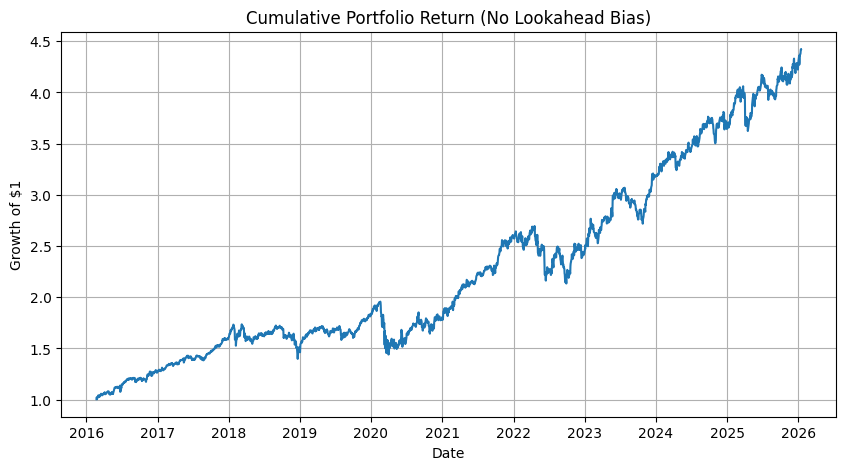

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cum_return)
plt.title("Cumulative Portfolio Return (No Lookahead Bias)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()


In [82]:
print("Final portfolio value:", cum_return.iloc[-1])
print("Total days:", len(cum_return))


Final portfolio value: 4.421924971702697
Total days: 2490


In [85]:
portfolio_returns.describe()


count    2490.000000
mean        0.000597
std         0.010738
min        -0.106166
25%        -0.003999
50%         0.001164
75%         0.005928
max         0.084471
Name: next_day_return, dtype: float64

In [88]:
market_returns = (
    data.groupby("Date")["next_day_return"].mean()
)

market_cum = np.exp(market_returns.cumsum())


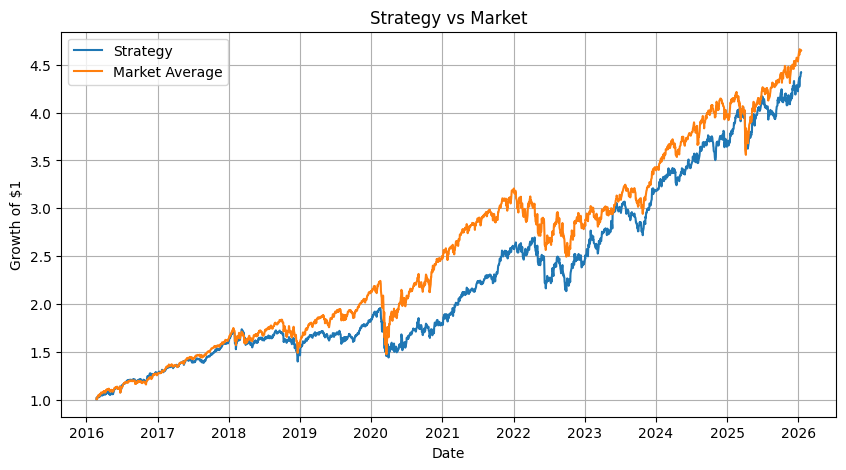

In [89]:
plt.figure(figsize=(10, 5))
plt.plot(cum_return, label="Strategy")
plt.plot(market_cum, label="Market Average")
plt.legend()
plt.title("Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()
